# Modelo RandomForest — Predicción de Crisis TACE

Este notebook unifica los features de las tres alertas, construye la etiqueta `Y` definitiva con las reglas acordadas, entrena el modelo y analiza los resultados.

**Reglas de la etiqueta Y (horizonte 18 meses)**:
- Clase `1` si cualquiera de las siguientes condiciones se cumple al momento `t+18`:
  - Recesión oficial NBER (6 episodios históricos).
  - Crash 1987: octubre 1987 a marzo 1988 (liquidación financiera TACE).
  - GDPC1 YoY `< 0` durante **al menos 2 meses consecutivos**.
- Clase `0` en todos los demás casos.

**Regla COVID 2020**: los meses febrero–abril 2020 se mantienen en el dataset para la curva histórica pero se **excluyen del entrenamiento** (shock exógeno, no ciclo TACE).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

DATA_DIR = Path('datos ABCT')
START_DATE = '1980-01-01'
END_DATE   = '2025-10-01'
TARGET_SHIFT_MONTHS = 18
RANDOM_STATE = 42
TRAIN_RATIO = 0.80        # corte temporal 80/20

# ── Periodos de recesión NBER ──────────────────────────────────────────────
NBER_PERIODS = [
    ('1980-01-01', '1980-07-01'),
    ('1981-07-01', '1982-11-01'),
    ('1990-07-01', '1991-03-01'),
    ('2001-03-01', '2001-11-01'),
    ('2007-12-01', '2009-06-01'),
    ('2020-02-01', '2020-04-01'),   # COVID: label 1 pero excluido del training
]
# Crash bursátil 1987 (liquidación financiera TACE)
BLACK_MONDAY = ('1987-10-01', '1988-03-01')
# Meses COVID que NO entran al training
COVID_EXCLUDE = ('2020-02-01', '2020-04-01')

In [2]:
def load_monthly_series(csv_path, value_col, date_col='observation_date'):
    df = pd.read_csv(csv_path)
    df[date_col] = pd.to_datetime(df[date_col])
    df = df[[date_col, value_col]].dropna()
    df = df.rename(columns={date_col: 'date', value_col: value_col.lower()})
    df = df.set_index('date').sort_index()
    df.index = df.index.to_period('M').to_timestamp(how='start')
    return df[value_col.lower()]

def monthly_interpolate_from_quarterly(series_q, start, end):
    monthly_idx = pd.date_range(start=start, end=end, freq='MS')
    return series_q.reindex(monthly_idx).interpolate(method='linear')

# ──────────────────────────────────────────────────────────────────────────
# Construcción autoritativa de Y
# ──────────────────────────────────────────────────────────────────────────
full_idx = pd.date_range(start=START_DATE, end=END_DATE, freq='MS')

# 1. NBER y 1987
crisis_base = pd.Series(0, index=full_idx, name='crisis_now')
for s, e in NBER_PERIODS:
    crisis_base.loc[pd.Timestamp(s):pd.Timestamp(e)] = 1
crisis_base.loc[pd.Timestamp(BLACK_MONDAY[0]):pd.Timestamp(BLACK_MONDAY[1])] = 1

# 2. GDPC1 < 0 durante al menos 2 meses consecutivos (criterio propio)
gdpc1_q = load_monthly_series(DATA_DIR / 'GDPC1 - trimestral - hasta 01oct2025.csv', 'GDPC1')
gdpc1_m = monthly_interpolate_from_quarterly(gdpc1_q, START_DATE, END_DATE)
gdpc1_yoy = gdpc1_m.pct_change(12) * 100
gdpc1_neg  = (gdpc1_yoy < 0).astype(int)
# rolling(2).sum() >= 2: ambos el mes actual y el anterior son negativos
gdpc1_consec = (gdpc1_neg.rolling(2, min_periods=2).sum() >= 2).astype(int)
crisis_base = (crisis_base | gdpc1_consec.reindex(full_idx).fillna(0).astype(int)).astype(int)

# 3. Horizonte 18 meses
y_series = crisis_base.shift(-TARGET_SHIFT_MONTHS).rename('y')

# 4. Flag COVID: kept en dataset pero se EXCLUYE del training
covid_flag = pd.Series(0, index=full_idx, name='covid_exclude')
covid_flag.loc[pd.Timestamp(COVID_EXCLUDE[0]):pd.Timestamp(COVID_EXCLUDE[1])] = 1

# Resumen
print(f'Meses clase 1 (crisis_now): {crisis_base.sum()}')
print(f'Meses clase 1 (Y t+18m): {y_series.dropna().astype(int).sum()}')
print(f'Meses marcados como COVID: {covid_flag.sum()}')

Meses clase 1 (crisis_now): 84
Meses clase 1 (Y t+18m): 77
Meses marcados como COVID: 3


In [3]:
# ──────────────────────────────────────────────────────────────────────────
# Merge de los tres datasets de features (inner join por fecha)
# ──────────────────────────────────────────────────────────────────────────
a1 = pd.read_csv('dataset_alerta1.csv', parse_dates=['date'], index_col='date')
a2 = pd.read_csv('dataset_alerta2.csv', parse_dates=['date'], index_col='date').drop(columns='y_crisis_t_plus_18m')
a3 = pd.read_csv('dataset_alerta3.csv', parse_dates=['date'], index_col='date').drop(columns='y_crisis_t_plus_18m')

features_full = a1.join(a2, how='inner').join(a3, how='inner')

# Unir con Y autoritativa y flag COVID
aux = pd.DataFrame({'y': y_series, 'covid_exclude': covid_flag})
df_full = features_full.join(aux, how='inner').dropna()
df_full['y'] = df_full['y'].astype(int)

print('Dataset final:')
print(f'  Rango: {df_full.index.min().date()} → {df_full.index.max().date()}')
print(f'  Filas: {len(df_full)}')
print(f'  Features: {len(df_full.columns) - 2}')   # sin y ni covid_exclude
print('\nDistribución Y (completo):')
print(df_full['y'].value_counts(normalize=True).rename('proporcion'))
df_full.head()

Dataset final:
  Rango: 1982-12-01 → 2024-04-01
  Filas: 497
  Features: 22

Distribución Y (completo):
y
0    0.879276
1    0.120724
Name: proporcion, dtype: float64


,fedfunds,gs10,spread_yield_curve,ipbuseq_pce_ratio,ipbuseq_pce_ratio_ma6,ipbuseq_pce_ratio_yoy_pct,ipbuseq_pce_ratio_zscore24,nasdaq_gold_ratio,nasdaq_gold_ratio_ma6,nasdaq_gold_ratio_yoy_pct,nasdaq_gold_ratio_zscore24,ussthpi_gold_ratio,ussthpi_gold_ratio_ma6,ussthpi_gold_ratio_yoy_pct,ussthpi_gold_ratio_zscore24,busloans_psavert_ratio,busloans_psavert_ratio_ma6,busloans_psavert_ratio_yoy_pct,busloans_psavert_ratio_zscore24,cpi_yoy_pct,cpi_yoy_pct_ma6,cpi_yoy_pct_zscore24,y,covid_exclude
date,,,,,,,,,,,,,,,,,,,,,,,,
1982-12-01,8.95,10.54,1.59,0.012528,0.012950,-17.276294,-1.698110,0.524253,0.489575,9.049660,0.940480,0.255118,0.275796,-1.856111,-0.233793,35.967147,33.662912,27.314535,2.194739,3.825717,5.133174,-1.852696,0,0
1983-01-01,8.68,10.46,1.78,0.012464,0.012745,-13.900828,-1.583684,0.501731,0.489794,2.694199,0.446447,0.237549,0.262851,-14.026657,-0.782468,35.422198,34.446029,25.778599,1.760648,3.707627,4.658215,-1.723491,0,0
1983-02-01,8.51,10.72,2.21,0.012398,0.012596,-16.357552,-1.482569,0.521408,0.500103,6.814975,0.822856,0.233800,0.252209,-18.222948,-0.938182,35.121036,35.154744,16.838487,1.493738,3.484688,4.244781,-1.647747,0,0
1983-03-01,8.77,10.51,1.74,0.012386,0.012481,-15.358980,-1.365615,0.634863,0.535372,20.994291,2.852545,0.274728,0.256083,-15.825474,0.140546,36.804187,35.718427,22.352126,1.804285,3.590285,4.019675,-1.462799,0,0
1983-04-01,8.80,10.40,1.60,0.012278,0.012419,-14.661712,-1.331552,0.645740,0.562510,24.393668,2.533458,0.267488,0.256628,-13.727207,-0.143547,38.099602,36.229198,31.428746,1.917382,4.000000,3.847655,-1.196081,0,0


In [4]:
# ──────────────────────────────────────────────────────────────────────────
# Partición temporal 80/20 — sin data leakage
# ──────────────────────────────────────────────────────────────────────────
feature_cols = [c for c in df_full.columns if c not in ('y', 'covid_exclude')]

# Corte temporal estricto
n_total = len(df_full)
cutoff_idx = int(n_total * TRAIN_RATIO)
cutoff_date = df_full.index[cutoff_idx]

df_train_raw = df_full.iloc[:cutoff_idx].copy()
df_test  = df_full.iloc[cutoff_idx:].copy()

# Excluir meses COVID del training
df_train = df_train_raw[df_train_raw['covid_exclude'] == 0].copy()

X_train = df_train[feature_cols]
y_train = df_train['y']
X_test  = df_test[feature_cols]
y_test  = df_test['y']

print(f'Corte temporal: {cutoff_date.date()}')
print(f'Train: {len(X_train)} meses  |  clase 1: {y_train.sum()} ({y_train.mean()*100:.1f}%)')
print(f'Test : {len(X_test)}  meses  |  clase 1: {y_test.sum()} ({y_test.mean()*100:.1f}%)')
print(f'Meses COVID excluidos del training: {df_train_raw["covid_exclude"].sum()}')

Corte temporal: 2016-01-01
Train: 397 meses  |  clase 1: 50 (12.6%)
Test : 100  meses  |  clase 1: 10 (10.0%)
Meses COVID excluidos del training: 0


In [5]:
# ──────────────────────────────────────────────────────────────────────────
# Entrenamiento RandomForest
# ──────────────────────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

print('Modelo entrenado.')
print(f'  Árboles: {rf.n_estimators}')
print(f'  Max depth: {rf.max_depth}')
print(f'  Class weight: {rf.class_weight}')
print()
print('── Reporte sobre test set ──')
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Equilibrio (0)', 'Crisis (1)']))

Modelo entrenado.
  Árboles: 100
  Max depth: 5
  Class weight: balanced

── Reporte sobre test set ──
                precision    recall  f1-score   support

Equilibrio (0)       0.90      1.00      0.95        90
    Crisis (1)       0.00      0.00      0.00        10

      accuracy                           0.90       100
     macro avg       0.45      0.50      0.47       100
  weighted avg       0.81      0.90      0.85       100



d:\Python Projects\crisis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Python Projects\crisis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Python Projects\crisis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


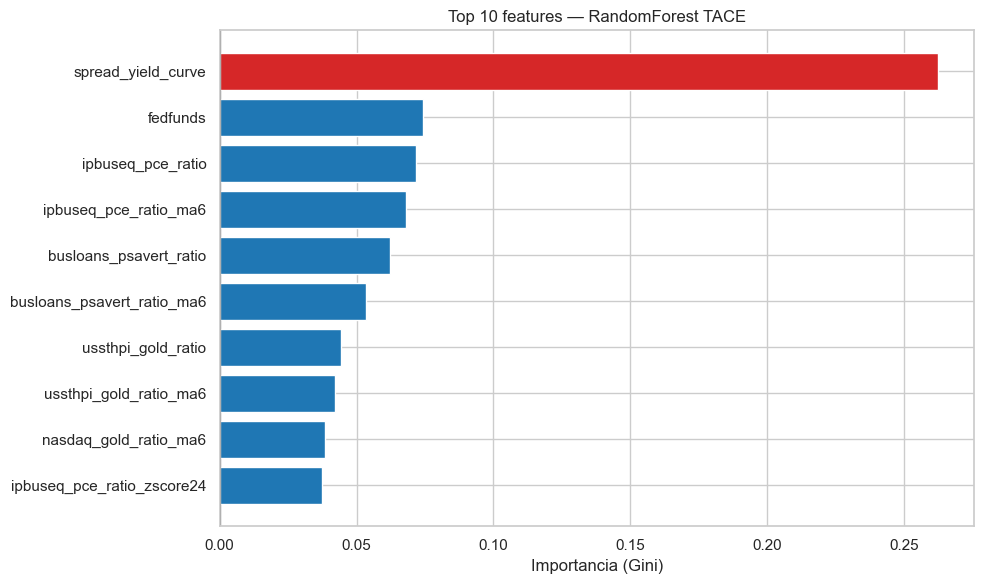


Importancia completa:
spread_yield_curve                 0.262410
fedfunds                           0.074326
ipbuseq_pce_ratio                  0.071846
ipbuseq_pce_ratio_ma6              0.068119
busloans_psavert_ratio             0.062177
busloans_psavert_ratio_ma6         0.053333
ussthpi_gold_ratio                 0.044448
ussthpi_gold_ratio_ma6             0.042299
nasdaq_gold_ratio_ma6              0.038501
ipbuseq_pce_ratio_zscore24         0.037464
gs10                               0.033075
nasdaq_gold_ratio                  0.029780
ipbuseq_pce_ratio_yoy_pct          0.025226
busloans_psavert_ratio_zscore24    0.024560
busloans_psavert_ratio_yoy_pct     0.022576
cpi_yoy_pct_ma6                    0.022328
cpi_yoy_pct_zscore24               0.019498
ussthpi_gold_ratio_zscore24        0.017125
cpi_yoy_pct                        0.016424
nasdaq_gold_ratio_yoy_pct          0.012812
nasdaq_gold_ratio_zscore24         0.010943
ussthpi_gold_ratio_yoy_pct         0.010731


In [6]:
# ──────────────────────────────────────────────────────────────────────────
# Importancia de variables — Top 10
# ──────────────────────────────────────────────────────────────────────────
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
top10 = importances.head(10)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#d62728' if i == 0 else '#1f77b4' for i in range(len(top10))]
ax.barh(top10.index[::-1], top10.values[::-1], color=colors[::-1])
ax.set_xlabel('Importancia (Gini)')
ax.set_title('Top 10 features — RandomForest TACE')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('\nImportancia completa:')
print(importances.to_string())

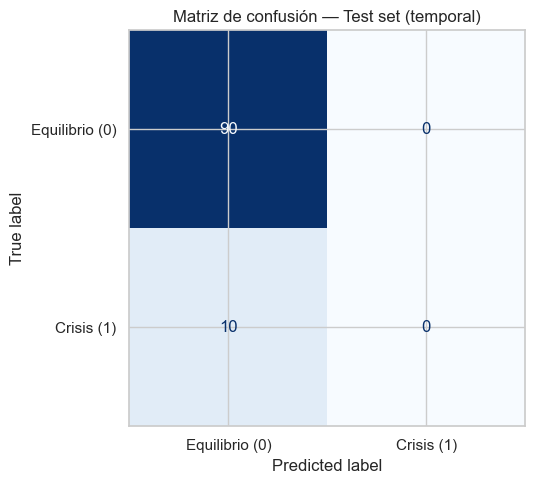

Crisis detectadas correctamente (Recall): 0.00%
Precisión en las alertas de crisis:       0.00%
Verdaderos Positivos: 0  |  Falsos Negativos (crisis perdidas): 10


In [7]:
# ──────────────────────────────────────────────────────────────────────────
# Matriz de confusión (sobre test set)
# ──────────────────────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Equilibrio (0)', 'Crisis (1)'])
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de confusión — Test set (temporal)')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
recall_crisis = tp / (tp + fn) if (tp + fn) > 0 else 0
precision_crisis = tp / (tp + fp) if (tp + fp) > 0 else 0
print(f'Crisis detectadas correctamente (Recall): {recall_crisis:.2%}')
print(f'Precisión en las alertas de crisis:       {precision_crisis:.2%}')
print(f'Verdaderos Positivos: {tp}  |  Falsos Negativos (crisis perdidas): {fn}')

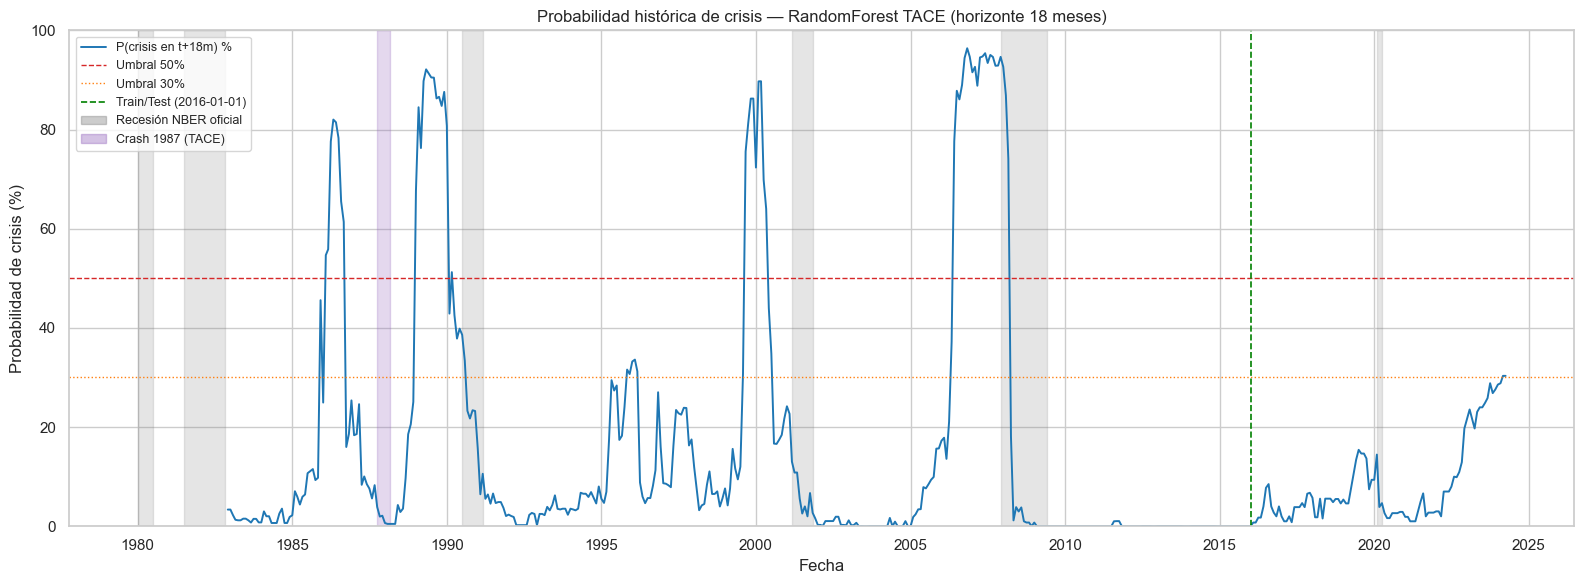

In [8]:
# ──────────────────────────────────────────────────────────────────────────
# Curva histórica de probabilidad de crisis (mes a mes)
# ──────────────────────────────────────────────────────────────────────────
prob_crisis = rf.predict_proba(df_full[feature_cols])[:, 1]
prob_series = pd.Series(prob_crisis * 100, index=df_full.index, name='prob_crisis_pct')

fig, ax = plt.subplots(figsize=(16, 6))

# Línea de probabilidad
ax.plot(prob_series.index, prob_series, color='#1f77b4', linewidth=1.4, label='P(crisis en t+18m) %')
ax.axhline(50, color='#d62728', linestyle='--', linewidth=1.0, label='Umbral 50%')
ax.axhline(30, color='#ff7f0e', linestyle=':', linewidth=1.0, label='Umbral 30%')

# Sombreado NBER (gris)
for s_str, e_str in NBER_PERIODS:
    s_ts, e_ts = pd.Timestamp(s_str), pd.Timestamp(e_str)
    ax.axvspan(s_ts, e_ts, alpha=0.20, color='grey', label='_nolegend_')

# Sombreado 1987 crash (guinda claro)
ax.axvspan(pd.Timestamp(BLACK_MONDAY[0]), pd.Timestamp(BLACK_MONDAY[1]),
           alpha=0.25, color='#9467bd', label='_nolegend_')

# Línea de corte train/test
ax.axvline(cutoff_date, color='green', linestyle='--', linewidth=1.2, label=f'Train/Test ({cutoff_date.date()})')

# Leyenda manual para áreas sombreadas
nber_patch   = mpatches.Patch(color='grey',    alpha=0.4, label='Recesión NBER oficial')
crash87_patch = mpatches.Patch(color='#9467bd', alpha=0.4, label='Crash 1987 (TACE)')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + [nber_patch, crash87_patch], loc='upper left', fontsize=9)

ax.set_xlabel('Fecha')
ax.set_ylabel('Probabilidad de crisis (%)')
ax.set_title('Probabilidad histórica de crisis — RandomForest TACE (horizonte 18 meses)')
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

## Evaluación avanzada del modelo

En esta sección se agregan métricas más robustas para clasificación desbalanceada y una validación temporal tipo walk-forward:

- AUC-PR (Average Precision)
- Brier Score (calibración probabilística)
- Calibration Curve
- Tabla de métricas por umbral
- Walk-Forward con ventana expansiva para evaluar estabilidad histórica

=== Evaluacion avanzada (test set temporal) ===
AUC-PR (Average Precision): 0.1166
Brier Score:                0.1026


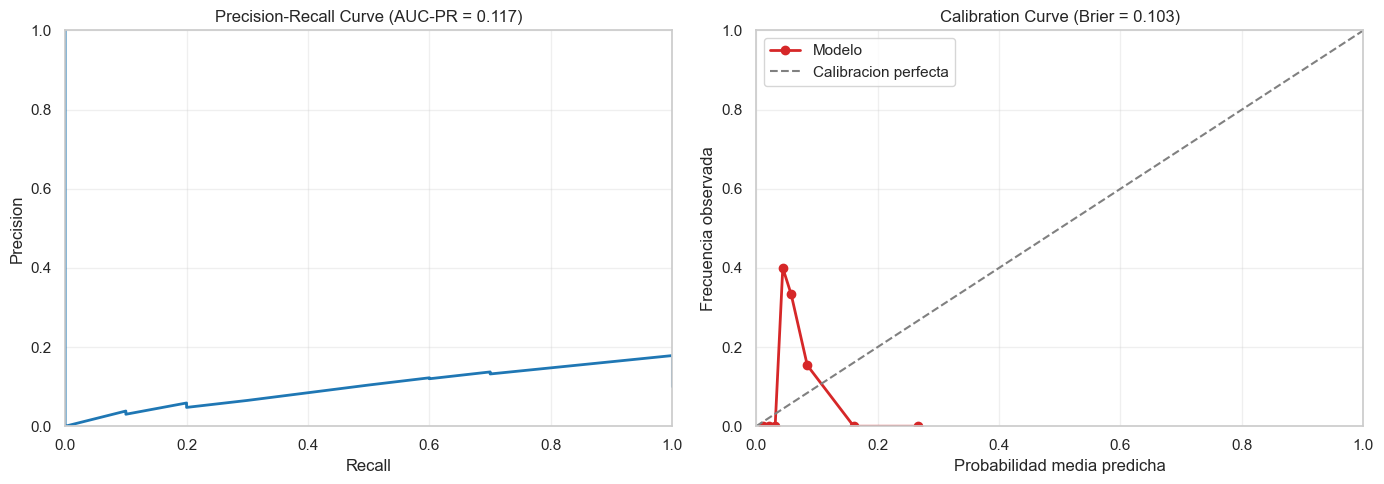


=== Metricas por umbral (test set) ===


,threshold,alerts,precision,recall,f1
0,0.10,27,0.037,0.1,0.054
1,0.15,18,0.000,0.0,0.000
2,0.20,15,0.000,0.0,0.000
3,0.25,8,0.000,0.0,0.000
4,0.30,2,0.000,0.0,0.000
5,0.35,0,0.000,0.0,0.000
6,0.40,0,0.000,0.0,0.000
7,0.45,0,0.000,0.0,0.000
8,0.50,0,0.000,0.0,0.000
9,0.55,0,0.000,0.0,0.000



=== Walk-Forward: resumen general ===
Iteraciones: 26
Promedio AP (solo ventanas con crisis): 0.9136
Promedio Brier:                         0.0817
Promedio Recall@30%:                   0.1346
Promedio Precision@30%:                0.1088

=== Tabla Walk-Forward (anual) ===


C:\Users\WINDOWS 10\AppData\Local\Temp\ipykernel_9984\2619325440.py:151: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(wf_results.round(3))


,train_end,test_start,test_end,n_test,positives,positive_rate,ap,brier,precision_30,recall_30,f1_30,avg_prob,max_prob
0,1997-11-01,1997-12-01,1998-11-01,12,0,0.000,NaN,0.023,0.000,0.0,0.000,0.146,0.190
1,1998-11-01,1998-12-01,1999-11-01,12,3,0.250,1.000,0.220,0.000,0.0,0.000,0.024,0.069
2,1999-11-01,1999-12-01,2000-11-01,12,6,0.500,0.733,0.251,0.429,0.5,0.462,0.347,0.654
3,2000-11-01,2000-12-01,2001-11-01,12,0,0.000,NaN,0.068,0.000,0.0,0.000,0.255,0.364
4,2001-11-01,2001-12-01,2002-11-01,12,0,0.000,NaN,0.000,0.000,0.0,0.000,0.020,0.030
5,2002-11-01,2002-12-01,2003-11-01,12,0,0.000,NaN,0.000,0.000,0.0,0.000,0.007,0.029
6,2003-11-01,2003-12-01,2004-11-01,12,0,0.000,NaN,0.002,0.000,0.0,0.000,0.027,0.089
7,2004-11-01,2004-12-01,2005-11-01,12,0,0.000,NaN,0.001,0.000,0.0,0.000,0.023,0.088
8,2005-11-01,2005-12-01,2006-11-01,12,6,0.500,0.917,0.473,0.000,0.0,0.000,0.014,0.044
9,2006-11-01,2006-12-01,2007-11-01,12,12,1.000,1.000,0.180,1.000,1.0,1.000,0.582,0.661



=== Walk-Forward: ventanas con crisis observada ===


C:\Users\WINDOWS 10\AppData\Local\Temp\ipykernel_9984\2619325440.py:163: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ]].round(3)


,test_start,test_end,positives,ap,brier,precision_30,recall_30,f1_30,avg_prob,max_prob
1,1998-12-01,1999-11-01,3,1.000,0.220,0.000,0.0,0.000,0.024,0.069
2,1999-12-01,2000-11-01,6,0.733,0.251,0.429,0.5,0.462,0.347,0.654
8,2005-12-01,2006-11-01,6,0.917,0.473,0.000,0.0,0.000,0.014,0.044
9,2006-12-01,2007-11-01,12,1.000,0.180,1.000,1.0,1.000,0.582,0.661
10,2007-12-01,2008-11-01,4,1.000,0.086,0.800,1.0,0.889,0.290,0.720
20,2017-12-01,2018-11-01,4,0.830,0.306,0.000,0.0,0.000,0.023,0.057
21,2018-12-01,2019-11-01,6,0.915,0.214,0.600,1.0,0.750,0.404,0.515


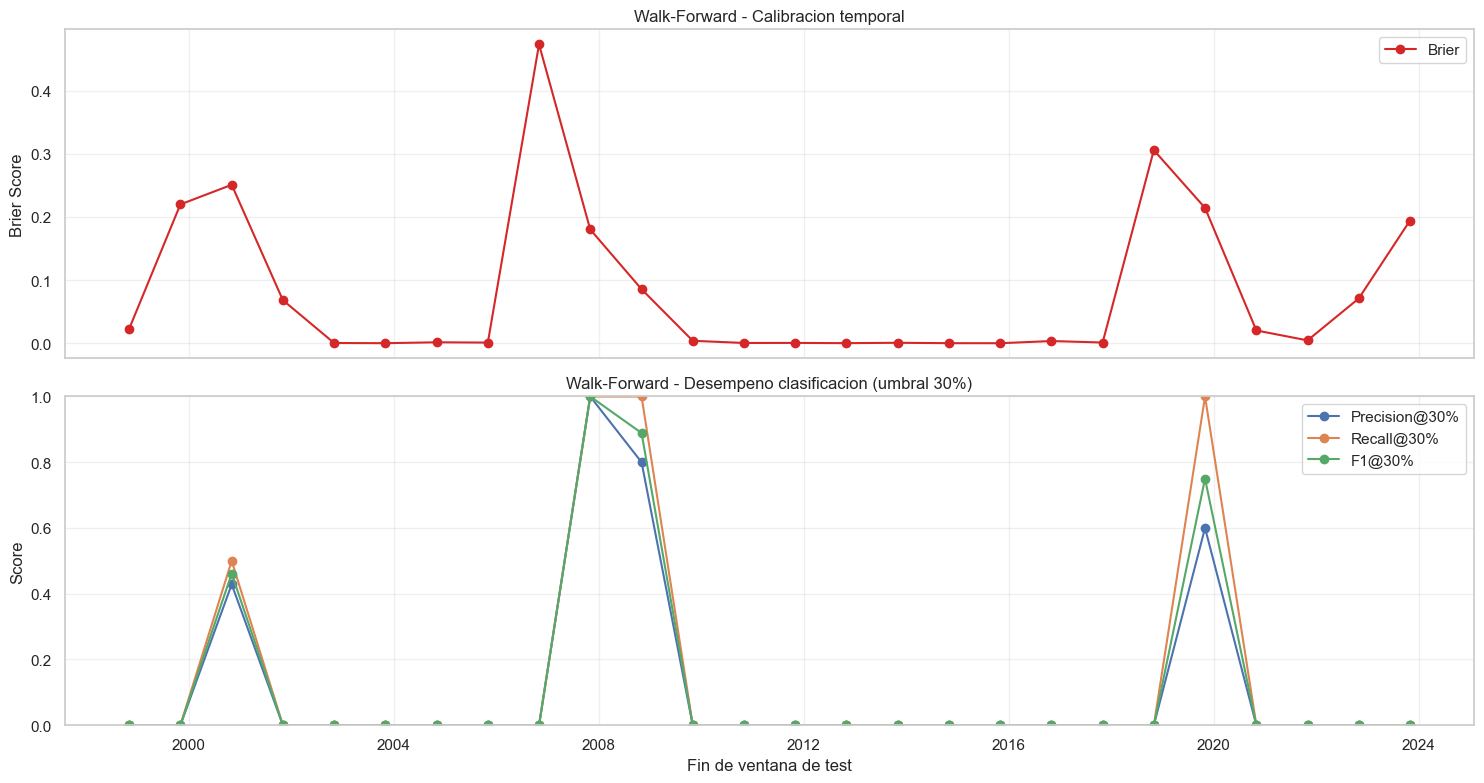

In [10]:
from sklearn.metrics import average_precision_score, precision_recall_curve, brier_score_loss
from sklearn.calibration import calibration_curve

# ==========================================================
# 1) Evaluación avanzada en el test set actual
# ==========================================================
y_test_prob = rf.predict_proba(X_test)[:, 1]

ap_test = average_precision_score(y_test, y_test_prob)
brier_test = brier_score_loss(y_test, y_test_prob)

print('=== Evaluacion avanzada (test set temporal) ===')
print(f'AUC-PR (Average Precision): {ap_test:.4f}')
print(f'Brier Score:                {brier_test:.4f}')

# Calibration curve
frac_pos, mean_pred = calibration_curve(y_test, y_test_prob, n_bins=8, strategy='quantile')

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Precision-Recall curve
precisions, recalls, pr_thresholds = precision_recall_curve(y_test, y_test_prob)
ax[0].plot(recalls, precisions, color='#1f77b4', linewidth=2)
ax[0].set_title(f'Precision-Recall Curve (AUC-PR = {ap_test:.3f})')
ax[0].set_xlabel('Recall')
ax[0].set_ylabel('Precision')
ax[0].set_xlim(0, 1)
ax[0].set_ylim(0, 1)
ax[0].grid(True, alpha=0.3)

# Calibration curve
ax[1].plot(mean_pred, frac_pos, marker='o', linewidth=2, color='#d62728', label='Modelo')
ax[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Calibracion perfecta')
ax[1].set_title(f'Calibration Curve (Brier = {brier_test:.3f})')
ax[1].set_xlabel('Probabilidad media predicha')
ax[1].set_ylabel('Frecuencia observada')
ax[1].set_xlim(0, 1)
ax[1].set_ylim(0, 1)
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Tabla de métricas por umbral
thresholds = np.arange(0.10, 0.91, 0.05)
rows = []

for th in thresholds:
    y_hat = (y_test_prob >= th).astype(int)
    tp = int(((y_test == 1) & (y_hat == 1)).sum())
    fp = int(((y_test == 0) & (y_hat == 1)).sum())
    fn = int(((y_test == 1) & (y_hat == 0)).sum())

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0

    rows.append({
        'threshold': round(float(th), 2),
        'alerts': int(y_hat.sum()),
        'precision': precision,
        'recall': recall,
        'f1': f1,
    })

threshold_metrics = pd.DataFrame(rows).sort_values('threshold').reset_index(drop=True)
print('\n=== Metricas por umbral (test set) ===')
display(threshold_metrics.round(3))

# ==========================================================
# 2) Walk-Forward Validation (expanding window)
# ==========================================================
wf_data = df_full.sort_index().copy()

min_train_months = 180  # 15 anios iniciales
step_months = 12        # avance anual
test_window_months = 12 # test de 1 anio por iteracion
wf_threshold = 0.30     # umbral de alerta temprana

wf_rows = []
for train_end in range(min_train_months, len(wf_data) - test_window_months + 1, step_months):
    train_slice_raw = wf_data.iloc[:train_end].copy()
    test_slice = wf_data.iloc[train_end:train_end + test_window_months].copy()

    # Excluir COVID solo del entrenamiento
    train_slice = train_slice_raw[train_slice_raw['covid_exclude'] == 0].copy()

    X_tr = train_slice[feature_cols]
    y_tr = train_slice['y']
    X_te = test_slice[feature_cols]
    y_te = test_slice['y']

    if y_tr.nunique() < 2:
        continue

    wf_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    wf_model.fit(X_tr, y_tr)

    y_prob = wf_model.predict_proba(X_te)[:, 1]
    y_hat = (y_prob >= wf_threshold).astype(int)

    # Metricas robustas ante ventanas sin clase positiva
    positives = int(y_te.sum())
    ap = average_precision_score(y_te, y_prob) if positives > 0 else np.nan
    brier = brier_score_loss(y_te, y_prob)

    tp = int(((y_te == 1) & (y_hat == 1)).sum())
    fp = int(((y_te == 0) & (y_hat == 1)).sum())
    fn = int(((y_te == 1) & (y_hat == 0)).sum())

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0

    wf_rows.append({
        'train_end': train_slice.index.max(),
        'test_start': test_slice.index.min(),
        'test_end': test_slice.index.max(),
        'n_test': len(test_slice),
        'positives': positives,
        'positive_rate': y_te.mean(),
        'ap': ap,
        'brier': brier,
        'precision_30': precision,
        'recall_30': recall,
        'f1_30': f1,
        'avg_prob': float(np.mean(y_prob)),
        'max_prob': float(np.max(y_prob)),
    })

wf_results = pd.DataFrame(wf_rows)

print('\n=== Walk-Forward: resumen general ===')
print(f'Iteraciones: {len(wf_results)}')
if len(wf_results) > 0:
    print(f'Promedio AP (solo ventanas con crisis): {wf_results["ap"].mean(skipna=True):.4f}')
    print(f'Promedio Brier:                         {wf_results["brier"].mean():.4f}')
    print(f'Promedio Recall@30%:                   {wf_results["recall_30"].mean():.4f}')
    print(f'Promedio Precision@30%:                {wf_results["precision_30"].mean():.4f}')

# Tabla completa de walk-forward
print('\n=== Tabla Walk-Forward (anual) ===')
if len(wf_results) > 0:
    display(wf_results.round(3))

# Resumen de ventanas con crisis (para ver comportamiento por ciclo)
wf_crisis_windows = wf_results[wf_results['positives'] > 0].copy()
print('\n=== Walk-Forward: ventanas con crisis observada ===')
if len(wf_crisis_windows) == 0:
    print('No hubo ventanas con crisis en esta configuracion.')
else:
    display(
        wf_crisis_windows[[
            'test_start', 'test_end', 'positives', 'ap', 'brier',
            'precision_30', 'recall_30', 'f1_30', 'avg_prob', 'max_prob'
        ]].round(3)
    )

# Grafico temporal de estabilidad walk-forward
if len(wf_results) > 0:
    fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

    axes[0].plot(wf_results['test_end'], wf_results['brier'], marker='o', color='#d62728', label='Brier')
    axes[0].set_title('Walk-Forward - Calibracion temporal')
    axes[0].set_ylabel('Brier Score')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(wf_results['test_end'], wf_results['precision_30'], marker='o', label='Precision@30%')
    axes[1].plot(wf_results['test_end'], wf_results['recall_30'], marker='o', label='Recall@30%')
    axes[1].plot(wf_results['test_end'], wf_results['f1_30'], marker='o', label='F1@30%')
    axes[1].set_title('Walk-Forward - Desempeno clasificacion (umbral 30%)')
    axes[1].set_ylabel('Score')
    axes[1].set_xlabel('Fin de ventana de test')
    axes[1].set_ylim(0, 1)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

## Selección automática de umbral (objetivo: Recall >= 0.70)

Esta celda selecciona el umbral de alerta usando predicciones **out-of-sample** de la validación walk-forward, priorizando sensibilidad (no perder crisis reales).

=== Seleccion automatica de Umbral de Alerta ===
Se logro Recall >= 0.70.
Umbral optimo de alerta: 0.06 (6.0%)
Precision esperada (WF OOS): 0.238
Recall esperado    (WF OOS): 0.732
F1 esperado        (WF OOS): 0.359
Alertas generadas en WF OOS: 126 de 312 meses

Probabilidad actual del modelo: 30.3%
¿Supera umbral optimo? True
Decision sugerida: SI, la lectura actual califica como senal de accion.


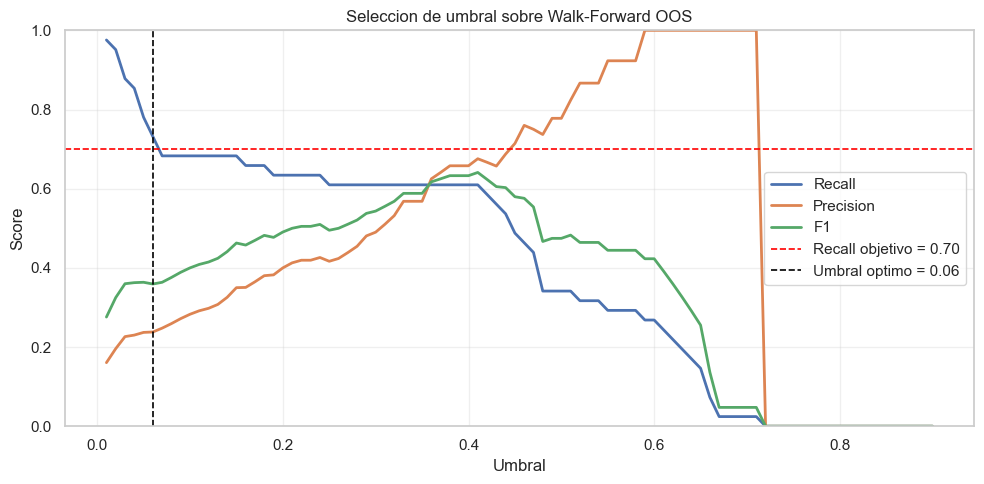


=== Tabla de seleccion (top por recall, luego precision) ===
 threshold  alerts  precision  recall    f1
      0.01     249      0.161   0.976 0.276
      0.02     199      0.196   0.951 0.325
      0.03     159      0.226   0.878 0.360
      0.04     152      0.230   0.854 0.363
      0.05     135      0.237   0.780 0.364
      0.06     126      0.238   0.732 0.359
      0.15      80      0.350   0.683 0.463
      0.14      86      0.326   0.683 0.441
      0.13      91      0.308   0.683 0.424
      0.12      94      0.298   0.683 0.415
      0.11      96      0.292   0.683 0.409
      0.10      99      0.283   0.683 0.400
      0.09     103      0.272   0.683 0.389
      0.08     108      0.259   0.683 0.376
      0.07     113      0.248   0.683 0.364


In [11]:
# ==========================================================
# Selección automática de umbral óptimo de alerta
# Criterio principal: Recall >= 0.70 (prioridad sensibilidad)
# ==========================================================
target_recall = 0.70

# 1) Construir predicciones out-of-sample de walk-forward
wf_oos_rows = []
for train_end in range(min_train_months, len(wf_data) - test_window_months + 1, step_months):
    train_slice_raw = wf_data.iloc[:train_end].copy()
    test_slice = wf_data.iloc[train_end:train_end + test_window_months].copy()

    train_slice = train_slice_raw[train_slice_raw['covid_exclude'] == 0].copy()

    X_tr = train_slice[feature_cols]
    y_tr = train_slice['y']
    X_te = test_slice[feature_cols]
    y_te = test_slice['y']

    if y_tr.nunique() < 2:
        continue

    wf_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    wf_model.fit(X_tr, y_tr)
    y_prob = wf_model.predict_proba(X_te)[:, 1]

    for d, yt, yp in zip(test_slice.index, y_te.values, y_prob):
        wf_oos_rows.append({'date': d, 'y_true': int(yt), 'y_prob': float(yp)})

wf_oos = pd.DataFrame(wf_oos_rows).sort_values('date').reset_index(drop=True)

# 2) Grid de umbrales y métricas
th_grid = np.arange(0.01, 0.91, 0.01)
sel_rows = []

for th in th_grid:
    y_hat = (wf_oos['y_prob'].values >= th).astype(int)
    y_true = wf_oos['y_true'].values

    tp = int(((y_true == 1) & (y_hat == 1)).sum())
    fp = int(((y_true == 0) & (y_hat == 1)).sum())
    fn = int(((y_true == 1) & (y_hat == 0)).sum())

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0

    sel_rows.append({
        'threshold': round(float(th), 2),
        'alerts': int(y_hat.sum()),
        'precision': precision,
        'recall': recall,
        'f1': f1,
    })

threshold_selection = pd.DataFrame(sel_rows)

# 3) Regla de selección automática
#    a) Elegibles: recall >= target
#    b) Entre elegibles: mayor precision
#    c) Desempate: mayor threshold (menos ruido con mismo desempeño)
eligible = threshold_selection[threshold_selection['recall'] >= target_recall].copy()

if len(eligible) > 0:
    optimal_row = eligible.sort_values(['precision', 'threshold'], ascending=[False, False]).iloc[0]
    feasibility_msg = f'Se logro Recall >= {target_recall:.2f}.'
else:
    # Fallback: si no se alcanza recall objetivo, elegir el de mayor recall
    optimal_row = threshold_selection.sort_values(['recall', 'precision', 'threshold'], ascending=[False, False, False]).iloc[0]
    feasibility_msg = f'No se logro Recall >= {target_recall:.2f}; se selecciona el mejor recall disponible.'

optimal_threshold = float(optimal_row['threshold'])
optimal_precision = float(optimal_row['precision'])
optimal_recall = float(optimal_row['recall'])
optimal_f1 = float(optimal_row['f1'])

# 4) Señal actual vs umbral óptimo
current_prob_pct = float(prob_series.iloc[-1])
current_prob = current_prob_pct / 100.0
signal_action = current_prob >= optimal_threshold

print('=== Seleccion automatica de Umbral de Alerta ===')
print(feasibility_msg)
print(f'Umbral optimo de alerta: {optimal_threshold:.2f} ({optimal_threshold*100:.1f}%)')
print(f'Precision esperada (WF OOS): {optimal_precision:.3f}')
print(f'Recall esperado    (WF OOS): {optimal_recall:.3f}')
print(f'F1 esperado        (WF OOS): {optimal_f1:.3f}')
print(f'Alertas generadas en WF OOS: {int(optimal_row["alerts"])} de {len(wf_oos)} meses')
print()
print(f'Probabilidad actual del modelo: {current_prob_pct:.1f}%')
print(f'¿Supera umbral optimo? {signal_action}')

if signal_action:
    print('Decision sugerida: SI, la lectura actual califica como senal de accion.')
else:
    print('Decision sugerida: NO, aun no califica como senal de accion con este criterio.')

# 5) Visual de apoyo: curva precision/recall por umbral
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(threshold_selection['threshold'], threshold_selection['recall'], label='Recall', linewidth=2)
ax.plot(threshold_selection['threshold'], threshold_selection['precision'], label='Precision', linewidth=2)
ax.plot(threshold_selection['threshold'], threshold_selection['f1'], label='F1', linewidth=2)
ax.axhline(target_recall, color='red', linestyle='--', linewidth=1.2, label=f'Recall objetivo = {target_recall:.2f}')
ax.axvline(optimal_threshold, color='black', linestyle='--', linewidth=1.2, label=f'Umbral optimo = {optimal_threshold:.2f}')
ax.set_title('Seleccion de umbral sobre Walk-Forward OOS')
ax.set_xlabel('Umbral')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print('\n=== Tabla de seleccion (top por recall, luego precision) ===')
print(
    threshold_selection
    .sort_values(['recall', 'precision', 'threshold'], ascending=[False, False, False])
    .head(15)
    .round(3)
    .to_string(index=False)
)

## Mejora 1 y 2: Ensamble RF + GBM y calibracion probabilistica

Esta seccion implementa dos mejoras directas del modelo:

1. Ensamble `RF + GBM` con soft voting para mejorar capacidad predictiva.
2. Calibracion probabilistica (`isotonic`) sobre el ensamble para mejorar la calidad de las probabilidades y la decision por umbral.

In [14]:
from sklearn.ensemble import GradientBoostingClassifier, VotingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import average_precision_score, brier_score_loss

# ==========================================================
# A) Modelo ensamble RF + GBM
# ==========================================================
rf_base = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

gbm_base = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=2,
    random_state=RANDOM_STATE,
)

ensemble = VotingClassifier(
    estimators=[('rf', rf_base), ('gbm', gbm_base)],
    voting='soft',
    weights=[1.0, 1.0],
)

ensemble.fit(X_train, y_train)

ens_prob_test = ensemble.predict_proba(X_test)[:, 1]
ens_pred_test = (ens_prob_test >= 0.50).astype(int)

ens_ap = average_precision_score(y_test, ens_prob_test)
ens_brier = brier_score_loss(y_test, ens_prob_test)

tp = int(((y_test == 1) & (ens_pred_test == 1)).sum())
fp = int(((y_test == 0) & (ens_pred_test == 1)).sum())
fn = int(((y_test == 1) & (ens_pred_test == 0)).sum())
ens_precision_50 = tp / (tp + fp) if (tp + fp) > 0 else 0.0
ens_recall_50 = tp / (tp + fn) if (tp + fn) > 0 else 0.0

# ==========================================================
# B) Calibracion probabilistica del ensamble (isotonic)
# ==========================================================
# TimeSeriesSplit evita mezclar temporalmente al calibrar.
tscv = TimeSeriesSplit(n_splits=3)
calibrated_ensemble = CalibratedClassifierCV(
    estimator=ensemble,
    method='isotonic',
    cv=tscv,
)
calibrated_ensemble.fit(X_train, y_train)

cal_prob_test = calibrated_ensemble.predict_proba(X_test)[:, 1]
cal_pred_test_50 = (cal_prob_test >= 0.50).astype(int)

cal_ap = average_precision_score(y_test, cal_prob_test)
cal_brier = brier_score_loss(y_test, cal_prob_test)

tp_c = int(((y_test == 1) & (cal_pred_test_50 == 1)).sum())
fp_c = int(((y_test == 0) & (cal_pred_test_50 == 1)).sum())
fn_c = int(((y_test == 1) & (cal_pred_test_50 == 0)).sum())
cal_precision_50 = tp_c / (tp_c + fp_c) if (tp_c + fp_c) > 0 else 0.0
cal_recall_50 = tp_c / (tp_c + fn_c) if (tp_c + fn_c) > 0 else 0.0

# Evaluacion a umbral operativo (si existe el optimo anterior, lo usa)
threshold_operativo = float(optimal_threshold) if 'optimal_threshold' in globals() else 0.06
cal_pred_test_op = (cal_prob_test >= threshold_operativo).astype(int)

tp_o = int(((y_test == 1) & (cal_pred_test_op == 1)).sum())
fp_o = int(((y_test == 0) & (cal_pred_test_op == 1)).sum())
fn_o = int(((y_test == 1) & (cal_pred_test_op == 0)).sum())
cal_precision_op = tp_o / (tp_o + fp_o) if (tp_o + fp_o) > 0 else 0.0
cal_recall_op = tp_o / (tp_o + fn_o) if (tp_o + fn_o) > 0 else 0.0

# Comparativa compacta
results_compare = pd.DataFrame([
    {
        'modelo': 'RF original',
        'AUC_PR_test': float(ap_test),
        'Brier_test': float(brier_test),
        'Precision@50': float(precision_crisis),
        'Recall@50': float(recall_crisis),
    },
    {
        'modelo': 'Ensamble RF+GBM',
        'AUC_PR_test': float(ens_ap),
        'Brier_test': float(ens_brier),
        'Precision@50': float(ens_precision_50),
        'Recall@50': float(ens_recall_50),
    },
    {
        'modelo': 'Ensamble calibrado (isotonic)',
        'AUC_PR_test': float(cal_ap),
        'Brier_test': float(cal_brier),
        'Precision@50': float(cal_precision_50),
        'Recall@50': float(cal_recall_50),
    },
])

print('=== Comparativa de mejora de modelo ===')
display(results_compare.round(4))

print(f'\nUmbral operativo usado: {threshold_operativo:.2f} ({threshold_operativo*100:.1f}%)')
print(f'Calibrado - Precision@umbral operativo: {cal_precision_op:.3f}')
print(f'Calibrado - Recall@umbral operativo:    {cal_recall_op:.3f}')

# Probabilidad actual con ensamble calibrado
cal_prob_full = calibrated_ensemble.predict_proba(df_full[feature_cols])[:, 1]
cal_prob_series = pd.Series(cal_prob_full * 100, index=df_full.index, name='cal_prob_crisis_pct')
current_prob_cal_pct = float(cal_prob_series.iloc[-1])
signal_action_cal = current_prob_cal_pct / 100.0 >= threshold_operativo

print(f'\nProbabilidad actual (ensamble calibrado): {current_prob_cal_pct:.2f}%')
print(f'¿Senal de accion con ensamble calibrado?: {signal_action_cal}')

=== Comparativa de mejora de modelo ===


,modelo,AUC_PR_test,Brier_test,Precision@50,Recall@50
0,RF original,0.1166,0.1026,0.0,0.0
1,Ensamble RF+GBM,0.1194,0.1539,0.0,0.0
2,Ensamble calibrado (isotonic),0.1059,0.1254,0.0,0.0



Umbral operativo usado: 0.06 (6.0%)
Calibrado - Precision@umbral operativo: 0.100
Calibrado - Recall@umbral operativo:    1.000

Probabilidad actual (ensamble calibrado): 46.67%
¿Senal de accion con ensamble calibrado?: True


## Cierre de arquitectura: Isotonic vs Platt (objetivo Recall >= 0.70)

Se compara la calibracion `isotonic` versus `sigmoid` (Platt), se elige automaticamente la mejor bajo un objetivo de recall minimo de 0.70 y se genera la curva historica final del ensamble calibrado ganador.

=== Comparacion calibracion: Isotonic vs Platt ===
Recall objetivo minimo: 0.70


,method,feasible_recall_target,selected_threshold,precision_at_selected,recall_at_selected,f1_at_selected,AUC_PR_test,Brier_test
0,platt_sigmoid,True,0.04,0.1075,1.0,0.1942,0.0779,0.1110
1,isotonic,True,0.13,0.1000,1.0,0.1818,0.1059,0.1254


Metodo ganador: platt_sigmoid
Umbral seleccionado: 0.04 (4.0%)


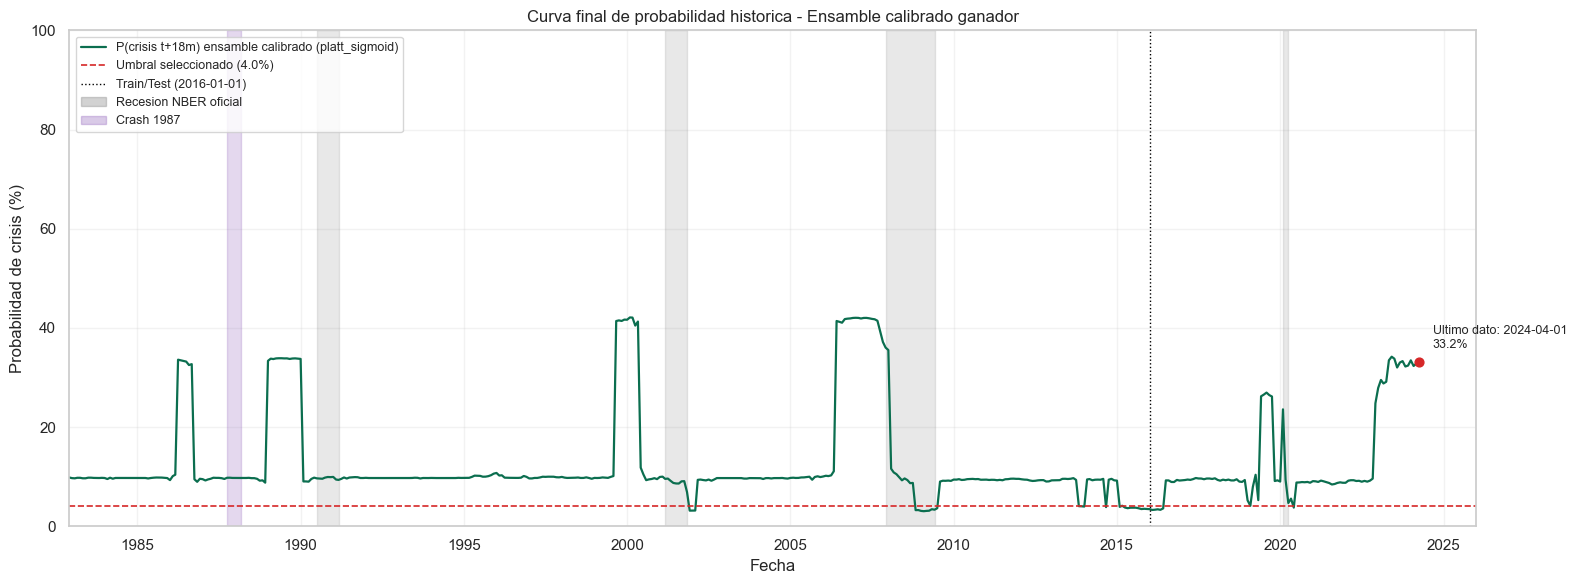


=== Lectura final del modelo cerrado ===
Metodo de calibracion elegido: platt_sigmoid
Umbral operativo final: 4.0%
Ultima probabilidad disponible: 33.16% (2024-04-01)
Senal de accion final: True


In [15]:
from sklearn.metrics import average_precision_score, brier_score_loss

# ==========================================================
# 1) Calibracion dual: Isotonic vs Platt (sigmoid)
# ==========================================================
target_recall_final = 0.70

# Reentrenamos ensamble base para dejar esta seccion autocontenida
rf_base_final = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

gbm_base_final = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=2,
    random_state=RANDOM_STATE,
)

ensemble_final = VotingClassifier(
    estimators=[('rf', rf_base_final), ('gbm', gbm_base_final)],
    voting='soft',
    weights=[1.0, 1.0],
)
ensemble_final.fit(X_train, y_train)

# Calibradores
cal_iso = CalibratedClassifierCV(estimator=ensemble_final, method='isotonic', cv=TimeSeriesSplit(n_splits=3))
cal_platt = CalibratedClassifierCV(estimator=ensemble_final, method='sigmoid', cv=TimeSeriesSplit(n_splits=3))

cal_iso.fit(X_train, y_train)
cal_platt.fit(X_train, y_train)

iso_prob_test = cal_iso.predict_proba(X_test)[:, 1]
platt_prob_test = cal_platt.predict_proba(X_test)[:, 1]

def pick_threshold_by_recall(y_true, y_prob, target_recall=0.70):
    grid = np.arange(0.01, 0.91, 0.01)
    rows = []
    for th in grid:
        y_hat = (y_prob >= th).astype(int)
        tp = int(((y_true == 1) & (y_hat == 1)).sum())
        fp = int(((y_true == 0) & (y_hat == 1)).sum())
        fn = int(((y_true == 1) & (y_hat == 0)).sum())

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0

        rows.append({
            'threshold': float(th),
            'alerts': int(y_hat.sum()),
            'precision': precision,
            'recall': recall,
            'f1': f1,
        })

    table = pd.DataFrame(rows)
    eligible = table[table['recall'] >= target_recall].copy()

    if len(eligible) > 0:
        best = eligible.sort_values(['precision', 'threshold'], ascending=[False, False]).iloc[0]
        feasible = True
    else:
        best = table.sort_values(['recall', 'precision', 'threshold'], ascending=[False, False, False]).iloc[0]
        feasible = False

    return best, feasible, table

iso_best, iso_feasible, iso_table = pick_threshold_by_recall(y_test.values, iso_prob_test, target_recall_final)
platt_best, platt_feasible, platt_table = pick_threshold_by_recall(y_test.values, platt_prob_test, target_recall_final)

iso_ap = average_precision_score(y_test, iso_prob_test)
iso_brier = brier_score_loss(y_test, iso_prob_test)
platt_ap = average_precision_score(y_test, platt_prob_test)
platt_brier = brier_score_loss(y_test, platt_prob_test)

compare_cal = pd.DataFrame([
    {
        'method': 'isotonic',
        'feasible_recall_target': bool(iso_feasible),
        'selected_threshold': float(iso_best['threshold']),
        'precision_at_selected': float(iso_best['precision']),
        'recall_at_selected': float(iso_best['recall']),
        'f1_at_selected': float(iso_best['f1']),
        'AUC_PR_test': float(iso_ap),
        'Brier_test': float(iso_brier),
    },
    {
        'method': 'platt_sigmoid',
        'feasible_recall_target': bool(platt_feasible),
        'selected_threshold': float(platt_best['threshold']),
        'precision_at_selected': float(platt_best['precision']),
        'recall_at_selected': float(platt_best['recall']),
        'f1_at_selected': float(platt_best['f1']),
        'AUC_PR_test': float(platt_ap),
        'Brier_test': float(platt_brier),
    },
])

# Regla de eleccion final: cumple recall objetivo -> mayor precision -> mayor recall -> menor brier -> mayor AUC-PR
compare_sorted = compare_cal.sort_values(
    ['feasible_recall_target', 'precision_at_selected', 'recall_at_selected', 'Brier_test', 'AUC_PR_test'],
    ascending=[False, False, False, True, False]
).reset_index(drop=True)

winner = compare_sorted.iloc[0]
best_method = winner['method']
best_threshold = float(winner['selected_threshold'])

if best_method == 'isotonic':
    best_calibrator = cal_iso
    best_prob_test = iso_prob_test
else:
    best_calibrator = cal_platt
    best_prob_test = platt_prob_test

print('=== Comparacion calibracion: Isotonic vs Platt ===')
print(f'Recall objetivo minimo: {target_recall_final:.2f}')
display(compare_sorted.round(4))
print(f"Metodo ganador: {best_method}")
print(f"Umbral seleccionado: {best_threshold:.2f} ({best_threshold*100:.1f}%)")

# ==========================================================
# 2) Curva historica final con calibrador ganador
# ==========================================================
best_prob_full = best_calibrator.predict_proba(df_full[feature_cols])[:, 1]
best_prob_series = pd.Series(best_prob_full * 100, index=df_full.index, name='best_ensemble_prob_pct')

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(best_prob_series.index, best_prob_series, color='#0b6e4f', linewidth=1.6,
        label=f'P(crisis t+18m) ensamble calibrado ({best_method})')

# Umbral seleccionado
ax.axhline(best_threshold * 100, color='#d62728', linestyle='--', linewidth=1.2,
           label=f'Umbral seleccionado ({best_threshold*100:.1f}%)')

# Sombreado NBER
for s_str, e_str in NBER_PERIODS:
    ax.axvspan(pd.Timestamp(s_str), pd.Timestamp(e_str), alpha=0.18, color='grey', label='_nolegend_')

# Sombreado 1987
ax.axvspan(pd.Timestamp(BLACK_MONDAY[0]), pd.Timestamp(BLACK_MONDAY[1]), alpha=0.25, color='#9467bd', label='_nolegend_')

# Train/Test original
ax.axvline(cutoff_date, color='black', linestyle=':', linewidth=1.0, label=f'Train/Test ({cutoff_date.date()})')

# Extiende eje para visualizar tramo final hasta 2026 aunque no haya datos nuevos
x_right = max(pd.Timestamp('2026-01-01'), best_prob_series.index.max())
ax.set_xlim(best_prob_series.index.min(), x_right)

# Ultimo punto disponible
last_date = best_prob_series.index.max()
last_prob = float(best_prob_series.iloc[-1])
ax.scatter([last_date], [last_prob], color='#d62728', s=40, zorder=5)
ax.annotate(f'Ultimo dato: {last_date.date()}\n{last_prob:.1f}%',
            xy=(last_date, last_prob), xytext=(10, 10), textcoords='offset points', fontsize=9)

nber_patch = mpatches.Patch(color='grey', alpha=0.35, label='Recesion NBER oficial')
crash_patch = mpatches.Patch(color='#9467bd', alpha=0.35, label='Crash 1987')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + [nber_patch, crash_patch], loc='upper left', fontsize=9)

ax.set_title('Curva final de probabilidad historica - Ensamble calibrado ganador')
ax.set_xlabel('Fecha')
ax.set_ylabel('Probabilidad de crisis (%)')
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# Lectura final operativa
signal_action_best = (last_prob / 100.0) >= best_threshold
print('\n=== Lectura final del modelo cerrado ===')
print(f'Metodo de calibracion elegido: {best_method}')
print(f'Umbral operativo final: {best_threshold*100:.1f}%')
print(f'Ultima probabilidad disponible: {last_prob:.2f}% ({last_date.date()})')
print(f'Senal de accion final: {signal_action_best}')

## Inference extendida hasta el ultimo mes disponible

Esta seccion separa entrenamiento (con `y`) de inferencia (solo features) para proyectar la probabilidad de crisis hasta el ultimo mes disponible en los CSV crudos.

Nota metodologica:
- Para series trimestrales (ej. `USSTHPI`) se interpola a mensual y se aplica `forward-fill` al final para no truncar la inferencia por baja frecuencia.

=== Cobertura inferencia extendida ===
Inicio: 1982-12-01
Fin:    2025-09-01
Filas:  514


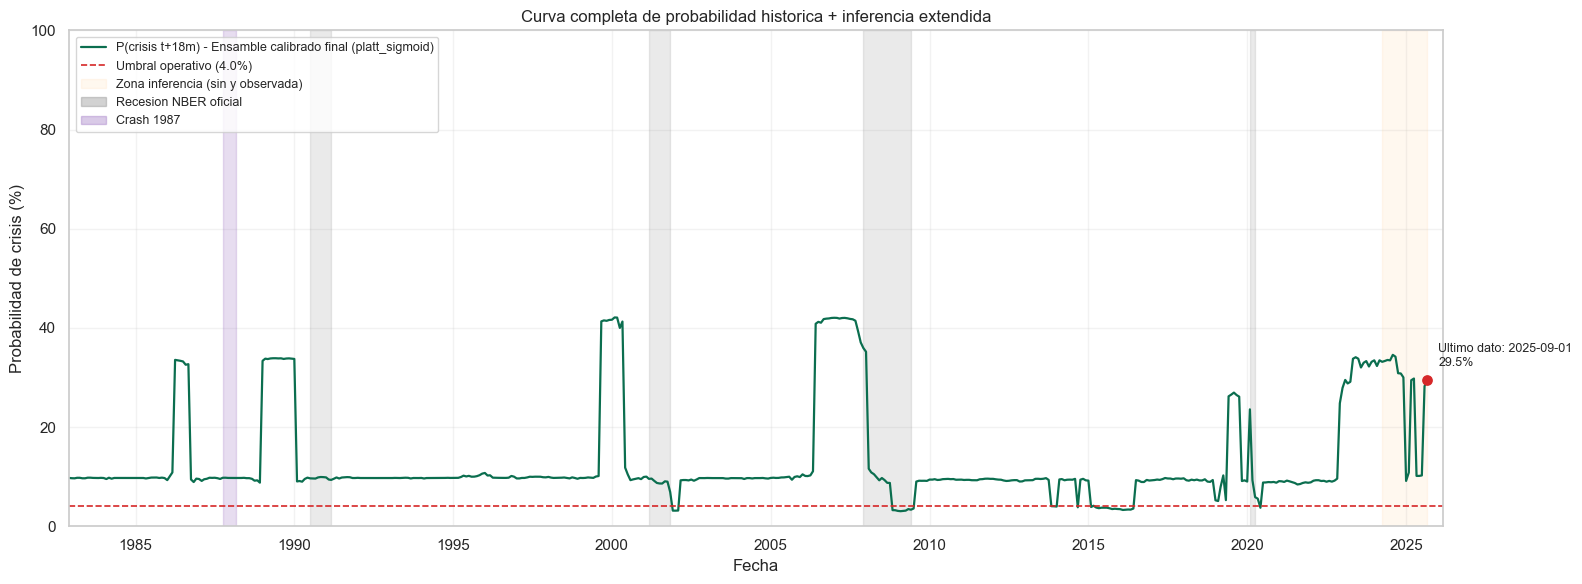


=== Lectura de riesgo mas reciente ===
Modelo usado para inferencia: Ensamble calibrado final (platt_sigmoid)
Ultima fecha disponible en features: 2025-09-01
Probabilidad estimada: 29.51%
Umbral operativo: 4.0%
Senal de accion: True
No hay fila exacta 2026-03-01 con features completas; se reporta el ultimo mes disponible.


In [16]:
# ==========================================================
# Inference extendida: reconstruccion de features desde CSV crudos
# ==========================================================

def _load_monthly_fred(csv_name, value_col):
    s = load_monthly_series(DATA_DIR / csv_name, value_col)
    return s.rename(value_col.lower())

def _load_nasdaq_monthly(csv_name):
    d = pd.read_csv(DATA_DIR / csv_name)
    date_col = d.columns[0]
    val_col = d.columns[1]
    d[date_col] = pd.to_datetime(d[date_col], errors='coerce')
    d[val_col] = pd.to_numeric(d[val_col], errors='coerce')
    d = d.dropna(subset=[date_col, val_col]).set_index(date_col).sort_index()
    s = d[val_col].resample('MS').mean()
    return s.rename('nasdaqcom')

def _load_gold_monthly(csv_name):
    d = pd.read_csv(DATA_DIR / csv_name)
    # Esperado: Date, Price
    date_col = d.columns[0]
    price_col = d.columns[1]
    d[date_col] = pd.to_datetime(d[date_col], errors='coerce')
    d[price_col] = pd.to_numeric(d[price_col].astype(str).str.replace(',', '', regex=False), errors='coerce')
    d = d.dropna(subset=[date_col, price_col]).set_index(date_col).sort_index()
    d.index = d.index.to_period('M').to_timestamp(how='start')
    return d[price_col].rename('gold_price')

def _add_transforms(base_series, prefix):
    out = pd.DataFrame(index=base_series.index)
    out[prefix] = base_series
    out[f'{prefix}_ma6'] = base_series.rolling(6).mean()
    out[f'{prefix}_yoy_pct'] = base_series.pct_change(12) * 100
    roll_mean = base_series.rolling(24).mean()
    roll_std = base_series.rolling(24).std(ddof=0)
    out[f'{prefix}_zscore24'] = (base_series - roll_mean) / roll_std
    return out

# 1) Cargar series crudas
fedfunds = _load_monthly_fred('FEDFUNDS - mensual - hasta 2026.csv', 'FEDFUNDS')
gs10 = _load_monthly_fred('GS10 - mensual - hasta 2026.csv', 'GS10')
ipbuseq = _load_monthly_fred('IPBUSEQ - mensual - hasta 2026.csv', 'IPBUSEQ')
pce = _load_monthly_fred('PCE - mensual - hasta 2026.csv', 'PCE')
busloans = _load_monthly_fred('BUSLOANS - mensual - hasta 2026.csv', 'BUSLOANS')
cpi = _load_monthly_fred('CPIAUCSL - mensual - hasta 2026.csv', 'CPIAUCSL')
psavert = _load_monthly_fred('PSAVERT - Personal saving rate - hasta 2026.csv', 'PSAVERT')
nasdaq_m = _load_nasdaq_monthly('NASDAQCOM - 1980 a 2026.csv')
gold = _load_gold_monthly('Onza de oro - mensual - no ajustado por inflacion.csv')
ussthpi_q = _load_monthly_fred('USSTHPI - trimestral - hasta 01oct25.csv', 'USSTHPI')

# 2) Definir rango de inferencia por disponibilidad mensual alta frecuencia
max_infer = min(
    fedfunds.index.max(), gs10.index.max(), ipbuseq.index.max(), pce.index.max(),
    busloans.index.max(), cpi.index.max(), psavert.index.max(), nasdaq_m.index.max(), gold.index.max()
)

infer_idx = pd.date_range(start=START_DATE, end=max_infer, freq='MS')

# USSTHPI: quarterly -> mensual + ffill final para no truncar inferencia
ussthpi_m = ussthpi_q.reindex(infer_idx).interpolate(method='linear').ffill()

# 3) Reconstruir features equivalentes al entrenamiento
# Alert 1
a1_inf = pd.DataFrame(index=infer_idx)
a1_inf['fedfunds'] = fedfunds.reindex(infer_idx)
a1_inf['gs10'] = gs10.reindex(infer_idx)
a1_inf['spread_yield_curve'] = a1_inf['gs10'] - a1_inf['fedfunds']

# Alert 2
ipbuseq_pce_ratio = ipbuseq.reindex(infer_idx) / pce.reindex(infer_idx)
nasdaq_gold_ratio = nasdaq_m.reindex(infer_idx) / gold.reindex(infer_idx)
ussthpi_gold_ratio = ussthpi_m / gold.reindex(infer_idx)

a2_inf = pd.concat([
    _add_transforms(ipbuseq_pce_ratio, 'ipbuseq_pce_ratio'),
    _add_transforms(nasdaq_gold_ratio, 'nasdaq_gold_ratio'),
    _add_transforms(ussthpi_gold_ratio, 'ussthpi_gold_ratio'),
], axis=1)

# Alert 3
busloans_psavert_ratio = busloans.reindex(infer_idx) / psavert.reindex(infer_idx)
cpi_yoy_pct = cpi.reindex(infer_idx).pct_change(12) * 100

a3_inf = pd.DataFrame(index=infer_idx)
a3_inf = pd.concat([
    _add_transforms(busloans_psavert_ratio, 'busloans_psavert_ratio'),
], axis=1)
a3_inf['cpi_yoy_pct'] = cpi_yoy_pct
a3_inf['cpi_yoy_pct_ma6'] = a3_inf['cpi_yoy_pct'].rolling(6).mean()
roll_mean_cpi = a3_inf['cpi_yoy_pct'].rolling(24).mean()
roll_std_cpi = a3_inf['cpi_yoy_pct'].rolling(24).std(ddof=0)
a3_inf['cpi_yoy_pct_zscore24'] = (a3_inf['cpi_yoy_pct'] - roll_mean_cpi) / roll_std_cpi

# 4) Matriz final de inferencia (solo features)
X_infer_full = a1_inf.join(a2_inf, how='inner').join(a3_inf, how='inner')
X_infer_full = X_infer_full.reindex(columns=feature_cols)
X_infer_full = X_infer_full.dropna().copy()

print('=== Cobertura inferencia extendida ===')
print(f'Inicio: {X_infer_full.index.min().date()}')
print(f'Fin:    {X_infer_full.index.max().date()}')
print(f'Filas:  {len(X_infer_full)}')

# 5) Elegir modelo ganador disponible (calibrador final > calibrado previo > RF)
if 'best_calibrator' in globals():
    model_for_infer = best_calibrator
    model_name_infer = f'Ensamble calibrado final ({best_method})'
    threshold_infer = float(best_threshold) if 'best_threshold' in globals() else 0.06
elif 'calibrated_ensemble' in globals():
    model_for_infer = calibrated_ensemble
    model_name_infer = 'Ensamble calibrado (isotonic)'
    threshold_infer = float(optimal_threshold) if 'optimal_threshold' in globals() else 0.06
else:
    model_for_infer = rf
    model_name_infer = 'RF base'
    threshold_infer = float(optimal_threshold) if 'optimal_threshold' in globals() else 0.06

infer_prob = model_for_infer.predict_proba(X_infer_full)[:, 1]
infer_prob_series = pd.Series(infer_prob * 100, index=X_infer_full.index, name='infer_prob_crisis_pct')

# 6) Grafico final extendido
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(infer_prob_series.index, infer_prob_series, color='#0b6e4f', linewidth=1.6,
        label=f'P(crisis t+18m) - {model_name_infer}')

ax.axhline(threshold_infer * 100, color='#d62728', linestyle='--', linewidth=1.2,
           label=f'Umbral operativo ({threshold_infer*100:.1f}%)')

for s_str, e_str in NBER_PERIODS:
    ax.axvspan(pd.Timestamp(s_str), pd.Timestamp(e_str), alpha=0.16, color='grey', label='_nolegend_')
ax.axvspan(pd.Timestamp(BLACK_MONDAY[0]), pd.Timestamp(BLACK_MONDAY[1]), alpha=0.22, color='#9467bd', label='_nolegend_')

# Marcar desde donde deja de haber y (zona de inferencia pura)
if 'df_full' in globals():
    y_limit = df_full.index.max()
    if infer_prob_series.index.max() > y_limit:
        ax.axvspan(y_limit, infer_prob_series.index.max(), alpha=0.10, color='#ffbf69', label='Zona inferencia (sin y observada)')

# Intento mostrar hasta marzo 2026 si hay datos para ello
x_right = max(pd.Timestamp('2026-03-01'), infer_prob_series.index.max())
ax.set_xlim(infer_prob_series.index.min(), x_right)

last_date = infer_prob_series.index.max()
last_prob = float(infer_prob_series.iloc[-1])
signal_last = (last_prob / 100.0) >= threshold_infer

ax.scatter([last_date], [last_prob], color='#d62728', s=45, zorder=5)
ax.annotate(f'Ultimo dato: {last_date.date()}\n{last_prob:.1f}%',
            xy=(last_date, last_prob), xytext=(8, 10), textcoords='offset points', fontsize=9)

nber_patch = mpatches.Patch(color='grey', alpha=0.35, label='Recesion NBER oficial')
crash_patch = mpatches.Patch(color='#9467bd', alpha=0.35, label='Crash 1987')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + [nber_patch, crash_patch], loc='upper left', fontsize=9)

ax.set_title('Curva completa de probabilidad historica + inferencia extendida')
ax.set_xlabel('Fecha')
ax.set_ylabel('Probabilidad de crisis (%)')
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

print('\n=== Lectura de riesgo mas reciente ===')
print(f'Modelo usado para inferencia: {model_name_infer}')
print(f'Ultima fecha disponible en features: {last_date.date()}')
print(f'Probabilidad estimada: {last_prob:.2f}%')
print(f'Umbral operativo: {threshold_infer*100:.1f}%')
print(f'Senal de accion: {signal_last}')

# Dato explicito para marzo 2026 (si existe)
if pd.Timestamp('2026-03-01') in infer_prob_series.index:
    p_mar26 = float(infer_prob_series.loc[pd.Timestamp('2026-03-01')])
    print(f'Probabilidad en 2026-03-01: {p_mar26:.2f}%')
else:
    print('No hay fila exacta 2026-03-01 con features completas; se reporta el ultimo mes disponible.')